<h1 style="margin-top: 0;","margin-bottom: 0;"> Machine Learning Project</h1>
<h3 style="margin-top: 0;","margin-bottom: 0;">Modeling Breast Cancer Diagnoses using SVM and Neural Networks </h3>

Done by: Rohim Abdelaziz, Noor Ateya, Rokia Abdelaziz, and Rawan Al-Shal


This project aims to create two models to try and predict the diagnosis of a breast cancer tumors between being benignt or maligiant tumors. This project will create both an SVM method and a Neural Networks based method, investigate each one, and compile all the results into an academic paper to be submitted alongside this project. We will begin with the general imports needed for the entire project, then begin with the SVM model, followed by the neural networks one.

In [2]:
# imports

import time
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import learning_curve
from sklearn.metrics import PrecisionRecallDisplay, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.datasets import load_breast_cancer

# 1- SVM Model

In [3]:
#load the breast cancer data
data = pd.read_csv("/data.csv")

#preprocessing
data.head()

FileNotFoundError: [Errno 2] No such file or directory: '/data.csv'

In [ ]:
#drop id and unnamed as they do not provide any useful data to our model
data.drop(labels = ['id','Unnamed: 32'],axis = 1,inplace = True)

#encode the data since they can't be categorical
label_encoder = LabelEncoder()
data['diagnosis'] = label_encoder.fit_transform(data['diagnosis'])
print(data.shape)
print(data.head())

(569, 31)
   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...         25.38

In [ ]:
#afterwards, we detect highly correleated features and remove one from the pair
#based on variance (more informative / how much change across samples)

#correlation matrix
corrMatrix = data.corr().abs()

#upper triangle (avoid duplicate pairs) since a corr matrix is symmetric
upper = corrMatrix.where(np.triu(np.ones(corrMatrix.shape), k=1).astype(bool))

#get variance for each feature
variances = data.var()

#store the features we'll drop
to_drop = set()

#loop through corr matrix
for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] > 0.9:

            #compare the variance in the pair, drop the weaker one
            if variances[col] > variances[row]:
                to_drop.add(row)
            else:
                to_drop.add(col)

#drop selected features
data.drop(columns=list(to_drop), inplace=True)
print("dropped features:", to_drop)

#separate features and target
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

#split data 60 40 20
#use stratify so there isnt any class imbalances
X_train, X_remaining, y_train, y_remaining = train_test_split(X, y,test_size=0.4,random_state=42,stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_remaining, y_remaining,test_size=0.5,random_state=42,stratify=y_remaining)

#scale the data
scaler = StandardScaler()

#fit only on training data
X_train = scaler.fit_transform(X_train)

#transform validation and test using same scaler
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

dropped features: {'radius_mean', 'perimeter_se', 'radius_worst', 'texture_mean', 'radius_se', 'area_mean', 'concave points_mean', 'perimeter_mean', 'perimeter_worst'}


In [ ]:
#define the hyperparameters

#try different values of C for the regularization strength
#smaller = simpler, larger = tries to fit training data more closely
Cvalues = [0.001, 0.01, 0.1, 1, 10, 100]

#try different gamma values
#smaller gamma = smoother decision boundary
#larger = more complex, flexible boundary
gammavalues = [0.0001, 0.001, 0.01, 0.1, 1]

#store results
results = []

#try every combination of c and gamma (hyperparameter tuning)
for C in Cvalues:
    for gamma in gammavalues:

        #create svm model with rbf kernel
        model = SVC(kernel='rbf', C=C, gamma=gamma)

        #train model on training data
        model.fit(X_train, y_train)

        #predict on validation set only for tuning
        y_val_pred = model.predict(X_val)

        #measure performance on validation set
        val_accuracy = accuracy_score(y_val, y_val_pred)

        #store results for this parameter combination
        results.append({
            'C': C,
            'gamma': gamma,
            'val_accuracy': val_accuracy
        })

#find best hyperparameters

#convert results into a table for easier sorting
results_df = pd.DataFrame(results)

#sort by best validation accuracy and pick top row
best_row = results_df.sort_values(by='val_accuracy', ascending=False).iloc[0]

#get best hyperparameters
best_C = best_row['C']
best_gamma = best_row['gamma']

#train final model with best parameters

#combine training + val
X_final = np.vstack((X_train, X_val))
y_final = np.hstack((y_train, y_val))

#create final svm model using best parameters
best_model = SVC(kernel='rbf', C=best_C, gamma=best_gamma, probability=True)

#train final model and get the time
start = time.perf_counter()
best_model.fit(X_final, y_final)
train_time = time4.perf_counter() - start

#evaluate on the unseen test data

#predict test labels and get the time
start = time.perf_counter()
y_test_pred = best_model.predict(X_test)
test_time = time.perf_counter() - start

#get final metrics
accuracy = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Test Accuracy:", accuracy)
print("Test F1:", f1)
print(f"Training Time: {train_time:.6f} seconds")
print(f"Testing Time: {test_time:.6f} seconds")

Test Accuracy: 0.9824561403508771
Test F1: 0.975609756097561
Training Time: 0.013149 seconds
Testing Time: 0.001169 seconds


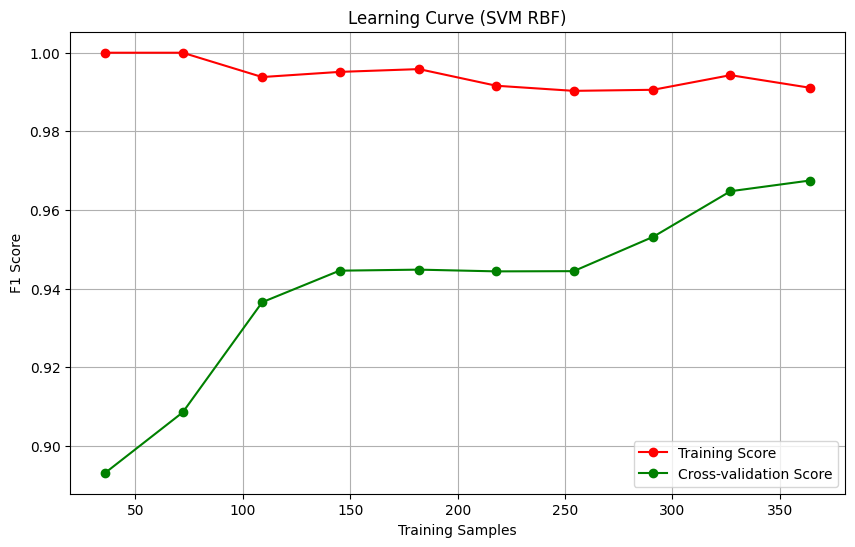

In [ ]:
# Calculate learning curve
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_final, y_final, cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

# Calculate mean scores
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation Score")
plt.title("Learning Curve (SVM RBF)")
plt.xlabel("Training Samples")
plt.ylabel("F1 Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

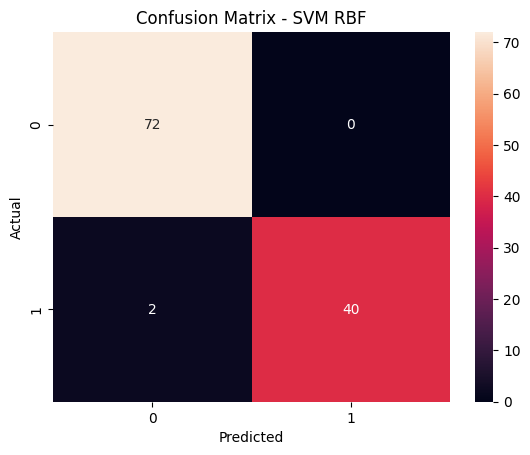

Number of support vectors: 41


In [ ]:
#confusion matrix
#according to the confusion matrix, the model perfoms well for medical data
#it has only 2 false negatives
cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - SVM RBF")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#computational complexity

#since svm predicts by "compare this new point to all support vectors
#(points near the boundary that defines where the line splits)"
#the number of support vectors determine complexity
print("Number of support vectors:", len(best_model.support_))

#since it is 41, around only 10% of the data,
#the model has a small prediction complexity

<Figure size 800x600 with 0 Axes>

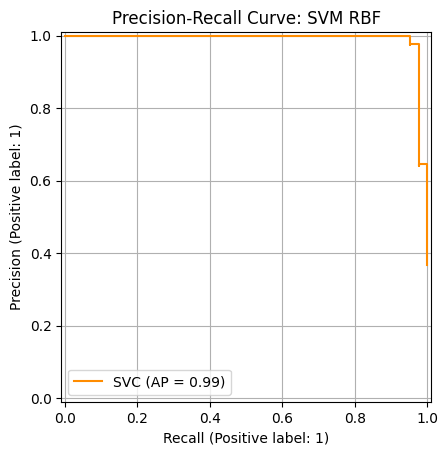

In [ ]:
# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, color='darkorange')
plt.title("Precision-Recall Curve: SVM RBF")
plt.grid(True)
plt.show()

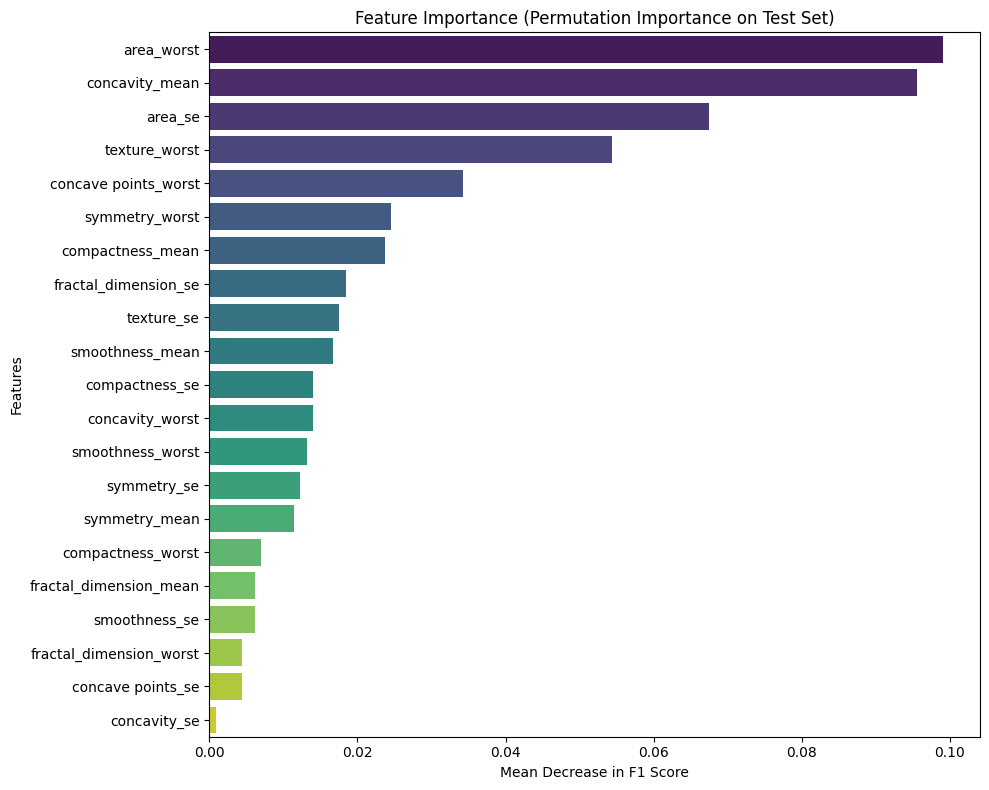

In [ ]:
# Calculate permutation importance
perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)

# Create a DataFrame for visualization
features_list = X.columns
importance_df = pd.DataFrame({'feature': features_list, 'importance': perm_importance.importances_mean})
importance_df = importance_df.sort_values(by='importance', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(
    x='importance',
    y='feature',
    data=importance_df,
    hue='feature',
    palette='viridis',
    legend=False
)
plt.title('Feature Importance (Permutation Importance on Test Set)')
plt.xlabel('Mean Decrease in F1 Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 2- Neural Networks Model

In [4]:
# loading the dataset
df = load_breast_cancer(as_frame=True).frame

# renaming columns for consistency
for column in df.columns:
    new_column = ""
    for letter in column:
        letter = letter.lower()
        if letter == " ":
            new_column += "_"
            continue
        new_column += letter

    df.rename(columns={column: new_column}, inplace=True)

In [5]:
# remapping the target (1 for malignant, 0 for benign)

df['target'] = df['target'].map(
    {
        1:0,
        0:1
    }
)

In [6]:
features_columns = df.columns
features_columns.drop('target')

Index(['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area',
       'mean_smoothness', 'mean_compactness', 'mean_concavity',
       'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension',
       'radius_error', 'texture_error', 'perimeter_error', 'area_error',
       'smoothness_error', 'compactness_error', 'concavity_error',
       'concave_points_error', 'symmetry_error', 'fractal_dimension_error',
       'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area',
       'worst_smoothness', 'worst_compactness', 'worst_concavity',
       'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension'],
      dtype='object')

## Correlation and General Data Analysis

In [ ]:
for column in df.columns:
    sns.histplot(df[column], kde=True)
    plt.show()

for column in df.columns:
    sns.boxplot(df[column], orient ='h')
    plt.show()

As we can see from this general data (as well as boxplots that were graphed and deleted for code cleaniness), we can see that although outliers exist, they are not extreme, and the features with extreme outliers are too few to affect the general model's performance, especially in the case of neural network models. Additionally, none of these features are normal, but since we do not need normal features for our model, we do not need to apply any log transformations.



In [10]:
# correlation analysis
corr_matrix = df.corr(numeric_only=True)
fig = px.imshow(corr_matrix, text_auto=True, aspect="auto", color_continuous_scale='RdBu_r')

fig.show()

From this, we can make two main inferences. Firstly, most features are correlated to one another since, for alot of them, we use one measurement and make a bunch of features. Most notably, the radius of a tumor also directly relates to its size, its perimeter, its worst radius, and so on and so worth. This relates to our second point, which is that these groupings, especially the radius-tied group, seems to be the most correlated to whether a tumor is safe or cancerous. In this database, 01 means its cancerous, while 0 means its safe. Due to the positive correlation between the target and all the numerical features, it means that the bigger all these values are, the more likely it is to be dangerous. It is important to keep this in mind in case these uncorrelated features bog down our model.

## Model Creation

In [ ]:
# defining features and target
features = df[features_columns]
target = df['target']

In [ ]:
# splitting the data
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
scaler = StandardScaler()

# creating the pipeline
neural_model = make_pipeline(scaler, MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42))

In [ ]:
# cross validation testing
cross_validation = cross_val_score(neural_model, x_train, y_train, cv=10, n_jobs=-1)
print(f"10-Fold CV Scores: {cross_validation}")
print(f"Average CV Accuracy: {cross_validation.mean():.4f}\n")

10-Fold CV Scores: [1.         1.         1.         0.97826087 1.         1.
 0.97777778 1.         1.         1.        ]
Average CV Accuracy: 0.9956



In [ ]:
# training the model (and timing it)
start = time.perf_counter()
neural_model.fit(x_train, y_train)
train_time = time.perf_counter() - start

# testing the model (and timing it)
start = time.perf_counter()
predictions = neural_model.predict(x_test)
test_time = time.perf_counter() - start
print(classification_report(y_test, predictions))
print(f"Training time: {train_time:.4f}.\nTesting time: {test_time:.4f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        71
           1       1.00      1.00      1.00        43

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114

Training time: 0.3536.
Testing time: 0.0029


From this, we can see that our model was able to find a perfect boundary between the safe and cancerous tumors. Keep in mind however, that the absolute 100% prediction rate of our model is not representative of a perfect model. Obviously our model is very accurate, but if we look at our CV scores, in which not all segments have 100% accuracy, we can identify that yes, our model is very accurate, but we also managed to receive a random training split which helped the model receive its 100% accuracy performance.
<br>
However, to double-check that there is no overfitting, we will re-create the model with a few changes. We will:
- Enable early stopping
- Enable Stratification

In [ ]:
# creating new model
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, stratify=target)

# creating the pipeline
new_neural_model = make_pipeline(scaler, MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42, early_stopping=True, n_iter_no_change=10))

In [ ]:
# cross validation testing
cross_validation = cross_val_score(new_neural_model, x_train, y_train, cv=10, n_jobs=-1)
print(f"10-Fold CV Scores: {cross_validation}")
print(f"Average CV Accuracy: {cross_validation.mean():.4f}\n")

10-Fold CV Scores: [0.95652174 0.95652174 0.95652174 0.97826087 0.97826087 0.97777778
 0.93333333 0.95555556 0.93333333 0.97777778]
Average CV Accuracy: 0.9604



In [ ]:
# training the model (and timing it)
start = time.perf_counter()
new_neural_model.fit(x_train, y_train)
train_time = time.perf_counter() - start

# testing the model (and timing it)
start = time.perf_counter()
predictions = new_neural_model.predict(x_test)
test_time = time.perf_counter() - start
print(classification_report(y_test, predictions))
print(f"Training time: {train_time:.4f}.\nTesting time: {test_time:.4f}")

              precision    recall  f1-score   support

           0       0.89      1.00      0.94        72
           1       1.00      0.79      0.88        42

    accuracy                           0.92       114
   macro avg       0.94      0.89      0.91       114
weighted avg       0.93      0.92      0.92       114

Training time: 0.0584.
Testing time: 0.0027


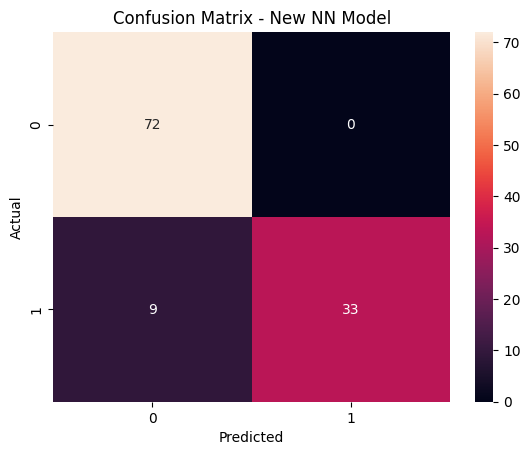

In [ ]:
# creating confusion matrix
new_model_confusion_matrix = confusion_matrix(y_test, predictions)

# displaying confusion matrix
sns.heatmap(new_model_confusion_matrix, annot=True, fmt='d')
plt.title("Confusion Matrix - New NN Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

As we can seem, this model is very accurate, but there is a fatal flaw, which is that all our errors are false negatives, which in this medical sense is incredibly dangerous. Since all errors were false negatives, this gives me the impression that this can be fixed by lowering the boundary at which the probability is equated to 1, which is 50% by default. However, before we resort to such a drastic change, we will first begin to try and optimize our model. This can come in two ways, either using the first model if it is not overfit, or by optimizing this model's parameters. We will begin with the first possibility.

When we asked the model to stop iterating after seeing improvements, it gave us this result, which implies that the original model was overfitted. This implies that the model was very accurate but then kept being overfitted to the data until it gave us the perfect accuracy we saw last time. However, the fact we got the same level of accuracy in all of the original model's cross validation parts gives me the impression that it cannot be overfitting, and may just be a case that early stopping is indeed lessening the power of the model. We will run some more tests. We will begin by graphing the cost of the function per iterations, and figure out where our model stopped and why.

Total iterations run in old model: 132
Total iterations run in new model: 14


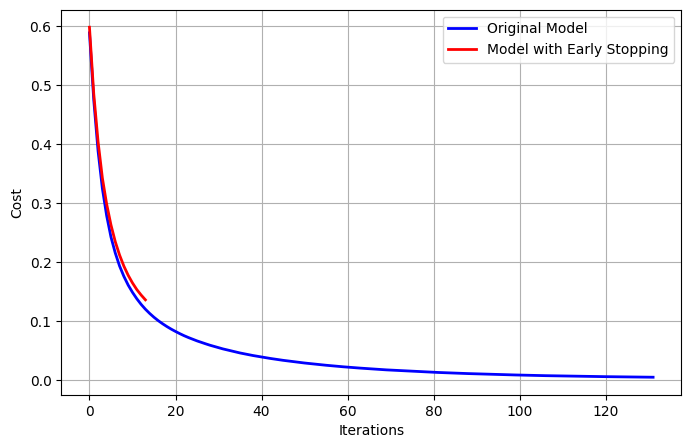

In [ ]:
# retrieving data
old_mlp_model = neural_model.named_steps['mlpclassifier']
new_mlp_model = new_neural_model.named_steps['mlpclassifier']

old_cost_history = old_mlp_model.loss_curve_
new_cost_history = new_mlp_model.loss_curve_

# printing exact information
print(f"Total iterations run in old model: {old_mlp_model.n_iter_}")
print(f"Total iterations run in new model: {new_mlp_model.n_iter_}")

# graphing data
plt.figure(figsize=(8, 5))
plt.plot(old_cost_history, color='blue', linewidth=2, label='Original Model')
plt.plot(new_cost_history, color='red', linewidth=2, label='Model with Early Stopping')

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.legend()

plt.show()

I personally hold the belief that the original model is not overfit due to the consistent CV scores. Despite this, just to be sure, we will use the model with early stopping. Seeing as this model can be improved, we will will try and optimize our parameters to get the most accurate model. For this, we will use GridSearch and a  variety of parameters.

In [ ]:
# listing the parameters we'd like to test
param_grid = {
    'mlpclassifier__hidden_layer_sizes': [(50,), (100,), (200,), (50,100), (50, 25), (100,50), (200,100)],
    'mlpclassifier__activation': ['relu', 'tanh'],
    'mlpclassifier__alpha': [0.0001, 0.001, 0.01],
    'mlpclassifier__learning_rate_init': [0.001, 0.01]
}

# running the testing function, which tries every combination of all the following parameters
grid_search = GridSearchCV(
    estimator=new_neural_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

# printing results
print(f"Highest CV Accuracy: {grid_search.best_score_:.4f}")
print("Best Parameters to achieve this:")
for param, value in grid_search.best_params_.items():
    print(f" - {param}: {value}")

Fitting 5 folds for each of 84 candidates, totalling 420 fits
Highest CV Accuracy: 0.9934
Best Parameters to achieve this:
 - mlpclassifier__activation: tanh
 - mlpclassifier__alpha: 0.0001
 - mlpclassifier__hidden_layer_sizes: (50, 100)
 - mlpclassifier__learning_rate_init: 0.01


In [ ]:
# creating model
optimized_neural_model = make_pipeline(scaler, MLPClassifier(hidden_layer_sizes=(50,100), early_stopping=True, learning_rate_init=0.01, max_iter=500, random_state=42, activation='tanh', alpha=0.0001))

# viewing cross validation results
cross_validation = cross_val_score(optimized_neural_model, x_train, y_train, cv=10, n_jobs=-1)
print(f"10-Fold CV Scores: {cross_validation}")
print(f"Average CV Accuracy: {cross_validation.mean():.4f}\n")

# training the model (and timing it)
start = time.perf_counter()
neural_model.fit(x_train, y_train)
train_time = time.perf_counter() - start

# testing the model (and timing it)
start = time.perf_counter()
predictions = neural_model.predict(x_test)
test_time = time.perf_counter() - start
print(classification_report(y_test, predictions))
print(f"Training time: {train_time:.4f}.\nTesting time: {test_time:.4f}")

10-Fold CV Scores: [0.97826087 1.         1.         1.         0.95652174 0.95555556
 1.         1.         0.97777778 1.        ]
Average CV Accuracy: 0.9868

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        72
           1       1.00      1.00      1.00        42

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114

Training time: 0.5161.
Testing time: 0.0030


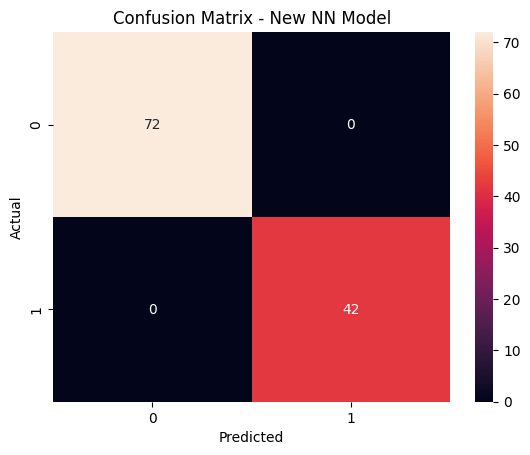

In [ ]:
# creating confusion matrix
optimized_neural_model_confusion_matrix = confusion_matrix(y_test, predictions)

# displaying confusion matrix
sns.heatmap(optimized_neural_model_confusion_matrix, annot=True, fmt='d')
plt.title("Confusion Matrix - New NN Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

As we can see, this model achieves perfect scores despite both stopping training earlier than needed, as well as having consistently high scores in the cross validation testing. Thus, I can confidently say this model is not overfit, and will thus be using it as our final neural network model

Since we have created a non-overfit model with perfect scoring, we have found it unneccessary to create a classifier fusion model, especially since over-training a model might create more overfitting, thus removing all the work we put into making it a general model. Thus, we will use this as our final breast cancer model.